### This was done in August, 2026.

# Sample Exam: Python Associate Exam - VoltBike Innovations

VoltBike Innovations is a leading company in the electric bicycle (e-bike) industry, specializing in the design and manufacture of high-performance e-bikes. The company is dedicated to advancing urban mobility solutions by delivering state-of-the-art e-bikes with features such as varying motor powers, advanced battery capacities, and efficient charge systems.

Recently, VoltBike Innovations has encountered some challenges in managing production costs while ensuring high levels of customer satisfaction. These issues have led to increased production expenses and variability in costs, impacting overall profitability.

You are part of the data analysis team tasked with providing actionable insights to help VoltBike Innovations address these challenges.

## Summary of Findings & Recommendations
VoltBike Innovations, in the interest of stabilizing production costs while also maintaining high levels of customer satisfaction, wants to evaluate factors causing rising production expesnses & variability & how they relate to customer satisfaction scores. This project explored data revolving around the production of the company's electric bicycles including variables like bike type, frame material, production cost, assembly time, top speed, battery type, motor power, & customer satisfaction scoers. In particular, it explored & examined the relationship between production cost & satisfaction score. There were 2,000 bike-customer pairs that comprised this dataset.

Following some straightforward preprocessing of the data (see **Task 1**), these two main variables of interest, along with assembly time, were aggregated across four different bike types (standard, folding, mountain, road, each of which had 490+ data points). For all three variables, the differences in the averages across the four bike types were rather minimal. Some notes from this analysis are listed below.
- Standard bikes typically cost \\$10+ less to produce than any other bike.
- Mountain bikes typically cost the most (about \\$17) yet take the least amount of time to produce (~ 59.8 minutes).
- The most highly rated bikes on average--road bikes (~ 6.56)--typically cost the second most (\\$503.02) & require the second most time (~ 61.2 minutes) of the four types to produce.

The most significant conclusion, given the difference in average production costs, is that standard bikes are the cheapest to make. Conversely, it is difficult to say with confidence that one type of bike in particular was quicker to make or more satisfying for the customer.
> As such, the company could alter their production strategies, which is fairly uniform based on this data (each bike type had between 490-514 data points each), towards producing more standard bikes & fewer mountain & road bikes.

The final section, **Task 3**, analyzed the 'production_cost' & 'customer_score' variables more directly by evaluating their distributions & their correlation. From these analyses, it appears that more money is invested into the production of bikes, customers are generally more satisfied with the product. More specifically, a scatterplot was made, illustrating a clear, linear relationship between these two variables, a relationship that possesses a weak-to-moderate, positive correlation of about 0.48. In other words, the more money that is spent in the production of a bike, customers are typically more satisfied with it & indicate this through a higher satisfaction score. To clarify, this metric does not indicate causation, but merely that the two variables change in relation to one another.


#### Recommendations
From **Task 2**, it was suggested that VoltBike could spend more time producing bikes that are cheaper to make, particularly standard bikes, & less on those that are most expensive for them (mountain & road bikes).

The results from **Task 3** unfortunately give more credence to a main problem that VoltBike is trying to remedy: managing production costs while ensuring high levels of customer satisfaction. Given that the relationship between these variables is positive & linear, an optimization strategy could be utilized to try & find the minimum production cost that maximizes both customer satisfaction & profits. Furthermore, this could be tuned across the four bike types. The other variables in the dataset could also be explored to see if they can help improve customer satisfaction without raising production costs.

On another note, there are other methods that could be used to enhance customer satisfaction aside from the functionality of the bike itself such as their relationship with the business. Perhaps VoltBike could offer additional incentives to further appeal to customers & enhance their experiences with their product such as advertisements, marketing, post-purchase deals (e.g. add ons, additional services). This would not necessarily impact bikes' production costs but may be able to increase customers' satisfaction with the product.

Alternatively, VoltBike could explore additional ways of lowering their production costs. Given their prioritization in producing "state-of-the-art high-performance bikes," this would be challenging without doing things like removing features or using cheaper materials. However, there might still be ways of doing so without harming satisfaction such as limiting production (not producing as many bikes), finding more cost-efficient production methods, & using more reliable materials that are not significantly more expensive.

### Import packages

In [43]:
import pandas as pd
import numpy as np
import statistics

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Task 1

Before you can start any analysis, you need to confirm that the data is accurate and reflects what you expect to see. 

It is known that there are some issues with the `production_data` table, and the data team have provided the following data description. 

Write a query to return data matching this description. You must match all column names and description criteria.
</br>
Create a cleaned version of the dataframe.

- You should start with the data in the file `ebike_data.csv`.
- Your output should be a dataframe named `clean_data`.
- All column names and values should match the table below.
</br>

| Column Name         | Criteria                                                                                         |
|----------------------|--------------------------------------------------------------------------------------------------|
| bike_type            | Categorical. Type of e-bike. ['standard', 'folding', 'mountain', 'road']. <br> Missing values should be replaced with 'standard'. |
| frame_material       | Categorical. Material of the e-bike frame. ['aluminum', 'steel', 'carbon fiber']. <br> Missing values should be replaced with 'unknown'. |
| production_cost      | Continuous. Cost of production (in USD). <br> Missing values should be replaced with median. |
| assembly_time        | Continuous. Time taken for assembly (in minutes). <br> Missing values should be replaced with mean, rounded to 2 decimal places. |
| top_speed            | Continuous. Maximum speed of the e-bike (in km/h). <br> Missing values should be replaced with mean, rounded to 2 decimal places |
| battery_type         | Categorical. Type of battery used. ['li-ion', 'nimh', 'lead acid']. <br> Missing values should be replaced with 'other'. |
| motor_power          | Continuous. Power output of the motor (in watts). <br> Missing values should be replaced with median. |
| customer_score       | Continuous. Customer satisfaction score (rating on a scale of 1 to 10). <br> Missing values should be replaced with mean, rounded to 2 decimal places |


#### Plan of Action:
- Import the data & evaluate it to determine what needs preprocessing.
    - Each variable was explored to check for inconsistencies & such.
        - 'bike_type': Object type (needs to be categorical).
        - 'frame_material': Object type (needs to be categorical), 40 "STEel" values.
        - 'production_cost': GOOD.
        - 'assembly_time': GOOD
        - 'top_speed': Missing values (NaNs).
        - 'battery_type': Object type (needs to be categorical), missing values ("-").
        - 'motor_power': Object type (needs to be continuous), values include a "W" (e.g. 317W) that need to be removed.
        - 'customer_score': Some (37) values exceed the acceptable range (> 10). Can round them down to the upper limit of 10.
- Clean data -- missing data, incorrect values, duplicates.
- Fix data types.
- Recheck cleaned data.

Upon importing the dataset, the data needs to be analyzed to determine what preprocessing steps are necessary. This was done by exploring the values of each variable.

In [44]:
#Import the dataset
orig_df = pd.read_csv("ebike_data.csv")

#Inspect the dataset
display(orig_df.info())
#orig_df.sample(5)

#Inspect individual variables
orig_df['customer_score'].value_counts(dropna=False)
#.sort_index(ascending=False)

#Check for duplicate data points -- NONE
#orig_df[orig_df.duplicated()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bike_type        2000 non-null   object 
 1   frame_material   2000 non-null   object 
 2   production_cost  2000 non-null   float64
 3   assembly_time    2000 non-null   float64
 4   top_speed        1940 non-null   float64
 5   battery_type     2000 non-null   object 
 6   motor_power      2000 non-null   object 
 7   customer_score   2000 non-null   float64
dtypes: float64(4), object(4)
memory usage: 125.1+ KB


None

customer_score
6.44     10
6.54     10
7.93     10
5.76     10
4.94      9
         ..
3.42      1
4.60      1
9.17      1
10.59     1
9.79      1
Name: count, Length: 645, dtype: int64

Various preprocessing steps need to be performed to the data including handling missing values, fixing inconsistencies, & adjusting data types. Fortunately, there are no duplicate data points.

In [45]:
#Clean the dataset, create a copy to avoid modifying the original
mod_df = orig_df.copy()

#Fix missing values -- 'top_speed', 'battery_type'
mod_df = mod_df.fillna({'top_speed': round(orig_df['top_speed'].mean(), 2)})
mod_df = mod_df.replace({'battery_type': {"-":"other"}})

#Fix inconsistencies in values
mod_df['frame_material'] = mod_df['frame_material'].apply(lambda x: x.lower())
mod_df['motor_power'] = mod_df['motor_power'].str.strip("W")
mod_df['customer_score'] = [10.0 if s>10 else s for s in mod_df['customer_score']]

#Fix data types
mod_df['bike_type'] = pd.Categorical(mod_df['bike_type'], categories=['standard','folding','mountain','road'], ordered=True)
mod_df['frame_material'] = pd.Categorical(mod_df['frame_material'], categories=['aluminum','steel','carbon fiber'], 
                                          ordered=True)
mod_df['battery_type'] = pd.Categorical(mod_df['battery_type'], categories=['li-ion','nimh','lead acid','other'], ordered=True)
mod_df['motor_power'] = mod_df['motor_power'].astype(float)

Now that the data has been preprocessed accordingly, the cleaned dataset needs to be rechecked to make sure it was done sufficiently. Then it can be defined accordingly; `clean_data`.

In [46]:
#Recheck cleaned data & define the variable appropriately
display(mod_df.info())
display(mod_df.sample(5))

clean_data = mod_df.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   bike_type        2000 non-null   category
 1   frame_material   2000 non-null   category
 2   production_cost  2000 non-null   float64 
 3   assembly_time    2000 non-null   float64 
 4   top_speed        2000 non-null   float64 
 5   battery_type     2000 non-null   category
 6   motor_power      2000 non-null   float64 
 7   customer_score   2000 non-null   float64 
dtypes: category(3), float64(5)
memory usage: 84.6 KB


None

,bike_type,frame_material,production_cost,assembly_time,top_speed,battery_type,motor_power,customer_score
405,folding,carbon fiber,562.58,40.32,24.11,lead acid,300.0,7.94
1843,mountain,aluminum,646.32,60.67,25.15,li-ion,287.0,7.60
1264,standard,aluminum,705.45,66.58,32.02,nimh,222.0,10.00
542,road,aluminum,498.35,62.10,22.55,li-ion,208.0,6.42
1185,road,aluminum,769.38,70.35,22.73,lead acid,297.0,7.40


# Task 2

You want to understand how different types of e-bikes influence production costs, assembly times, and customer satisfaction.  
Calculate the average production_cost, assembly_time, and customer_score grouped by bike_type.
- You should start with the data in the file `ebike_data.csv` (**ORIGINAL DATA**).
- Your output should be a data frame named `bike_type_data`.
- It should include the four columns:`bike_type`, `avg_production_cost`, `avg_assembly_time`, and `avg_customer_score`.
- Your answers should be rounded to 2 decimal places.



#### Plan of Action:
- Using the **original data**, need to group by 'bike_type' & calculate average 'production_cost', 'assembly_time', 'customer_score'. Round to 2 decimals.
- Organize data accordingly.
- Visualize &/or analyze the data.

In [47]:
#Calculate averages per bike_type
bike_type_data = orig_df.groupby('bike_type')[['production_cost','assembly_time','customer_score']].mean().apply(
                        lambda x: round(x,2)).reset_index()
#Rename columns
bike_type_data.columns = [['bike_type','avg_production_cost','avg_assembly_time','avg_customer_score']]
display(bike_type_data)

,bike_type,avg_production_cost,avg_assembly_time,avg_customer_score
0,folding,499.72,61.40,6.46
1,mountain,507.02,59.79,6.52
2,road,503.02,61.19,6.56
3,standard,489.85,59.81,6.50


Given the ranges of these three numerical variables, the averages across each bike type are quite similar. In other words, production costs, assembly times, & customer satisfaction scores differ by only a small level between bike types. Some interesting notes are listed below:
- Standard bikes typically cost \\$10+ less to produce than any other bike.
- Mountain bikes typically cost the most (about \\$17) yet take the least amount of time to produce (~ 59.8 minutes).
- The most highly rated bikes on average--road bikes (~ 6.56)--typically cost the second most (\\$503.02) & require the second most time (~ 61.2 minutes) of the four types to produce.

# Task 3

In order to proceed with further analysis, you need to understand how key production and satisfaction factors relate to each other. Start by calculating the mean and standard deviation for the following columns: `production_cost` and `customer_score`. These statistics will help in understanding the central tendency and variability of the data related to e-bike production and customer feedback.

Next, calculate the Pearson correlation coefficient between `production_cost` and `customer_score`. This correlation coefficient will provide insights into the strength and direction of the relationship between production costs and customer satisfaction.

- You should start with the data in the file `ebike_data.csv` (**ORIGINAL DATA**).
- Calculate the mean and standard deviation for the columns `production_cost` and `customer_score` as: `production_cost_mean`, `production_cost_sd`, `customer_score_mean`, and `customer_score_sd`.
- Calculate the Pearson correlation coefficient between `production_cost` and `customer_score` as `corr_coef`.
- Your output should be a data frame named `bike_analysis`.
- It should include the columns: `production_cost_mean`, `production_cost_sd`, `customer_score_mean`, `customer_score_sd`, and `corr_coef`.
- Ensure that your answers are rounded to 2 decimal places.



#### Plan of Action:
- Using the **original** data, calculate mean, standard deviation for 'production_cost', 'customer_score' to understand their centrality & variability. Round to 2 decimals.
- Calculate correlation between 'production_cost' & 'customer_score' to understand how they relate. Round to 2 decimals.
- Organize data accordingly.

C:\Users\elija\AppData\Local\Temp\ipykernel_27968\88431535.py:26: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(xmin=v[3]-v[4], xmax=v[3]+v[4], color='gray', edgecolor='black', alpha=0.35)
C:\Users\elija\AppData\Local\Temp\ipykernel_27968\88431535.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


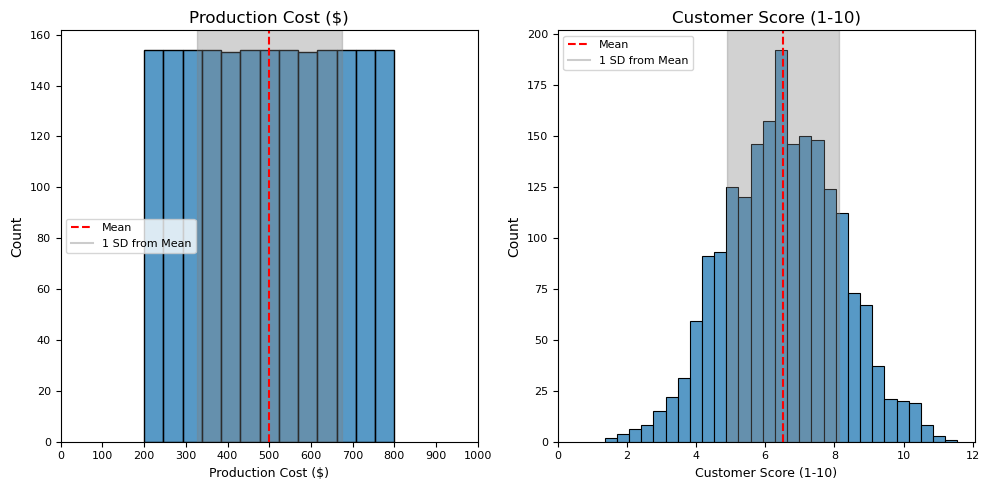

In [48]:
#Analyze distributions of 'production_cost', 'customer_score'

#Calculate their means, standard deviations
bike_analysis = pd.DataFrame(data=orig_df.agg({'production_cost':['mean','std'], 
                                               'customer_score':['mean','std']}).values.reshape(1,4),
                     columns=['production_cost_mean', 'customer_score_mean', 'production_cost_sd', 'customer_score_sd'])
#Need to reorganize columns
bike_analysis = bike_analysis[['production_cost_mean', 'production_cost_sd', 'customer_score_mean', 'customer_score_sd']]
#display(bike_analysis)


#Visualize the distributions
fig, axes = plt.subplots(ncols=2, figsize=(10,5))
ax1 = sns.histplot(data=orig_df, x='production_cost', ax=axes[0])
ax2 = sns.histplot(data=orig_df, x='customer_score', ax=axes[1])

#edit plot details
for k,v in {'Production Cost ($)':[0, 1001,100, bike_analysis['production_cost_mean'][0], 
                                   bike_analysis['production_cost_sd'][0], 'center left'], 
            'Customer Score (1-10)':[1, 13,2, bike_analysis['customer_score_mean'][0],
                                    bike_analysis['customer_score_sd'][0], 'upper left']}.items():
    plt.sca(axes[v[0]])
    #add the mean
    plt.axvline(v[3], linestyle='--', color='red')
    #identify data within 1 standard deviation of the mean
    plt.axvspan(xmin=v[3]-v[4], xmax=v[3]+v[4], color='gray', edgecolor='black', alpha=0.35)
    
    plt.title(k)
    plt.xlabel(k, fontsize=9)
    plt.xticks(ticks=range(0,v[1],v[2]), fontsize=8)
    plt.yticks(fontsize=8)
    #add a legend
    red_line = mlines.Line2D([], [], color='red', linestyle='--', label='Mean')
    gray_range = mlines.Line2D([], [], color='gray', alpha=0.4, label='1 SD from Mean')
    plt.legend(handles=[red_line, gray_range], fontsize=8, loc=v[5])
    plt.tight_layout();

The figures above illustrate the distributions of the production costs (in USD) & customer satisfaction scores (between 1-10) of bikes. There are 2,000 data points comprising this data. The vertical, dashed, red lines indicate the means of the distributions. The gray ranges indicate the data points that are within one standard deviation of the mean of each distribution.

The production-cost distribution is fairly uniform where most bikes cost somewhere between \\$200-\\$800 to produce. The average bike costs about \\$500 to make.  
The customer-satisfaction distribution is approximately normal in that it is fairly symmetric about its mean (about 6.5), which is approximated with the single peak. Most scores are between 5-8.
- Note that some values exceed the acceptable range of satisfaction scores (1-10). This is because the original data was used to construct these figures.

,production_cost_mean,production_cost_sd,customer_score_mean,customer_score_sd,corr_coef
0,500.0,173.34,6.51,1.63,0.48


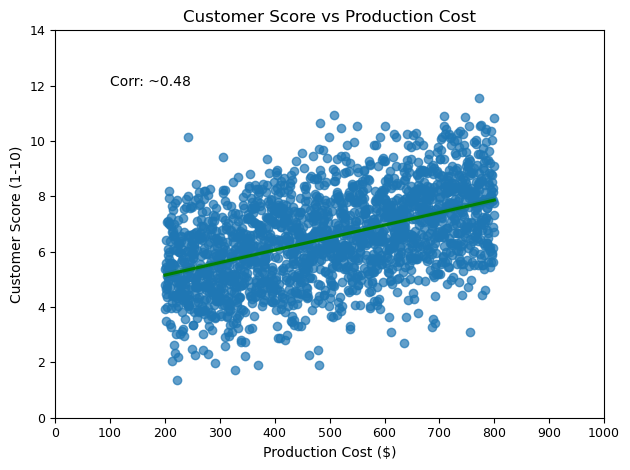

In [49]:
#Calculate correlation coefficients between 'production_cost', 'customer_score'
cost_score_corr = orig_df[['production_cost','customer_score']].corr(method='pearson').iloc[0,1]
bike_analysis['corr_coef'] = cost_score_corr

#Round all values to 2 decimals
bike_analysis = round(bike_analysis, 2)
display(bike_analysis)


#Visualize the data, display the regression line
ax1 = sns.regplot(data=orig_df, x='production_cost', y='customer_score', scatter_kws={'alpha':0.7}, line_kws={'color':'green'})
#edit plot details
plt.title('Customer Score vs Production Cost')
ax1.set(xlim=(0,1000), ylim=(0,14))
plt.xlabel('Production Cost ($)')
plt.xticks(ticks=range(0,1001,100), fontsize=9)
plt.ylabel('Customer Score (1-10)')
plt.yticks(ticks=range(0,15,2), fontsize=9)
#label the correlation of the relationship
plt.annotate(text=f"Corr: ~{round(cost_score_corr, 2)}", xy=(100,12))
plt.tight_layout();

The figure above displays customer satisfaction scores (on a scale from 1-10) against the production cost (in USD) of VoltBike's electric bicycles. This figure is composed of 2,000 bikes.

VoltBike, in the interest of increasing profitability & customer satisfaction, wants to evaluate the relationship between their customers' satisfaction in their products & the cost it takes to produce them. This figure shows a fairly clear, linear relationship between the two variables. More specifically, they have a correlation of about 0.48, indicating a small-to-moderate, positive relationship. In other words, the more expensive a bike is to produce, customers typically are more satisfied with it. The green, diagonal line indicates more clearly how these variables change in relation to one another. To clarify, this metric does not indicate causation, but merely that the two variables change in relation to one another.

As such, this finding reinforces the problem that VoltBike has been trying to diagnose--managing production costs while ensuring high levels of customer satisfaction. In the goal of lowering production costs, it might be worthwhile to find an optimal value that maximizes both customer satisfaction & profits. In other words, what is the minimum production cost of a bike that still leaves customers feeling highly satisfied whilst also maximizing profits.  
To determine this, other variables associated with bike production could be explored & how they relate to satisfaction & profits such as those in the dataset including bike type, frame material, assembly time, top speed, battery type, as well as other features of their bikes. These variables could be drilled down into to determine what specific features are most associated with higher satisfaction scores.  
On another note, there are other methods that could be used to enhance customer satisfaction aside from the functionality of the bike itself such as their relationship with the business. Perhaps VoltBike could offer additional incentives to further appeal to customers & enhance their experiences with their product such as advertisements, marketing, post-purchase deals (e.g. add ons, additional services). This would not necessarily impact bikes' production costs but may be able to increase customers' satisfaction with the product.  
Alternatively, VoltBike could explore ways of lowering their production costs. Given their prioritization in producing "state-of-the-art high-performance bikes," this would be challenging without doing things like removing features or using cheaper materials. However, there might still be ways of doing so without harming satisfaction such as limiting production (not producing as many bikes), finding more cost-efficient production methods, & using more reliable materials that are not significantly more expensive.